In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats

df = pd.read_csv('results/sbm_comparison.csv')

METHODS   = ['s_gd2', 'TorusMDS']
COLORS    = {'s_gd2': '#4C72B0', 'TorusMDS': '#DD8452'}
METRICS   = ['stress',  'np_score']
LABELS    = {
    'stress':     'Geodesic normalized stress',
    'distortion': 'Distortion',
    'sgs':        'SGS (Spearman rank corr.)',
    'np_score':   'Neighbourhood preservation',
    't_embed':    'Embedding time (s)',
}

data = {m: df[df['method'] == m] for m in METHODS}
print(df.groupby('method')[METRICS + ['t_embed']].agg(['mean','std']).round(4))

          stress         np_score         t_embed        
            mean     std     mean     std    mean     std
method                                                   
MDS       0.4001  0.0160   0.8553  0.1437  1.4636  2.2114
TorusMDS  0.3448  0.0194   0.8571  0.1394  1.1896  0.2716
s_gd2     0.4079  0.0142   0.8574  0.1427  0.1144  0.1470


## Violin plots

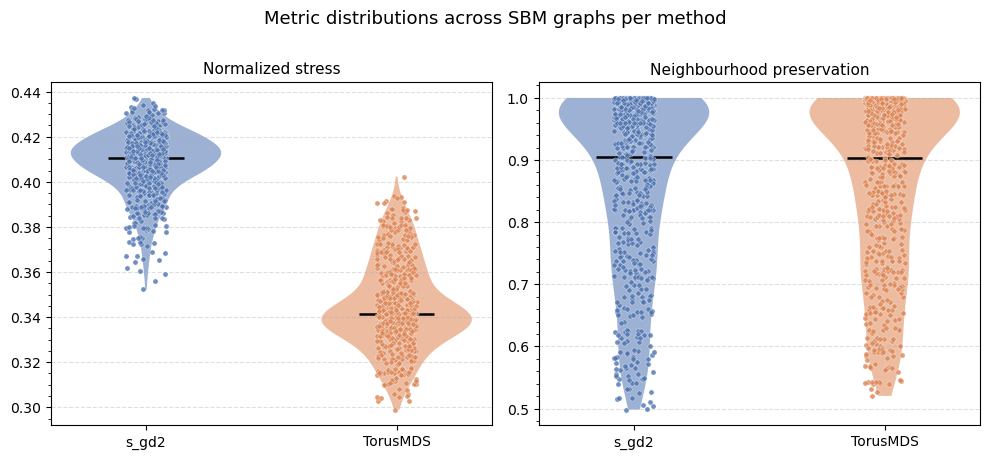

In [19]:
rng = np.random.default_rng(0)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

for ax, metric in zip(axes, METRICS):
    parts = ax.violinplot(
        [data[m][metric].values for m in METHODS],
        positions=range(len(METHODS)),
        widths=0.6,
        showmedians=True,
        showextrema=False,
    )
    for pc, m in zip(parts['bodies'], METHODS):
        pc.set_facecolor(COLORS[m])
        pc.set_alpha(0.55)
    parts['cmedians'].set_color('black')
    parts['cmedians'].set_linewidth(1.8)

    for xi, m in enumerate(METHODS):
        vals = data[m][metric].values
        jitter = rng.uniform(-0.08, 0.08, size=len(vals))
        ax.scatter(xi + jitter, vals, s=14, color=COLORS[m],
                   edgecolors='white', linewidths=0.3, zorder=3, alpha=0.8)

    ax.set_xticks(range(len(METHODS)))
    ax.set_xticklabels(METHODS, fontsize=10)
    ax.set_title(LABELS[metric], fontsize=11)
    ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())
    ax.grid(axis='y', which='major', linestyle='--', alpha=0.4)

fig.suptitle(f'Metric distributions across SBM graphs per method', fontsize=13, y=1.01)
fig.tight_layout()
plt.savefig('./results/sbm_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## Metrics vs graph size n

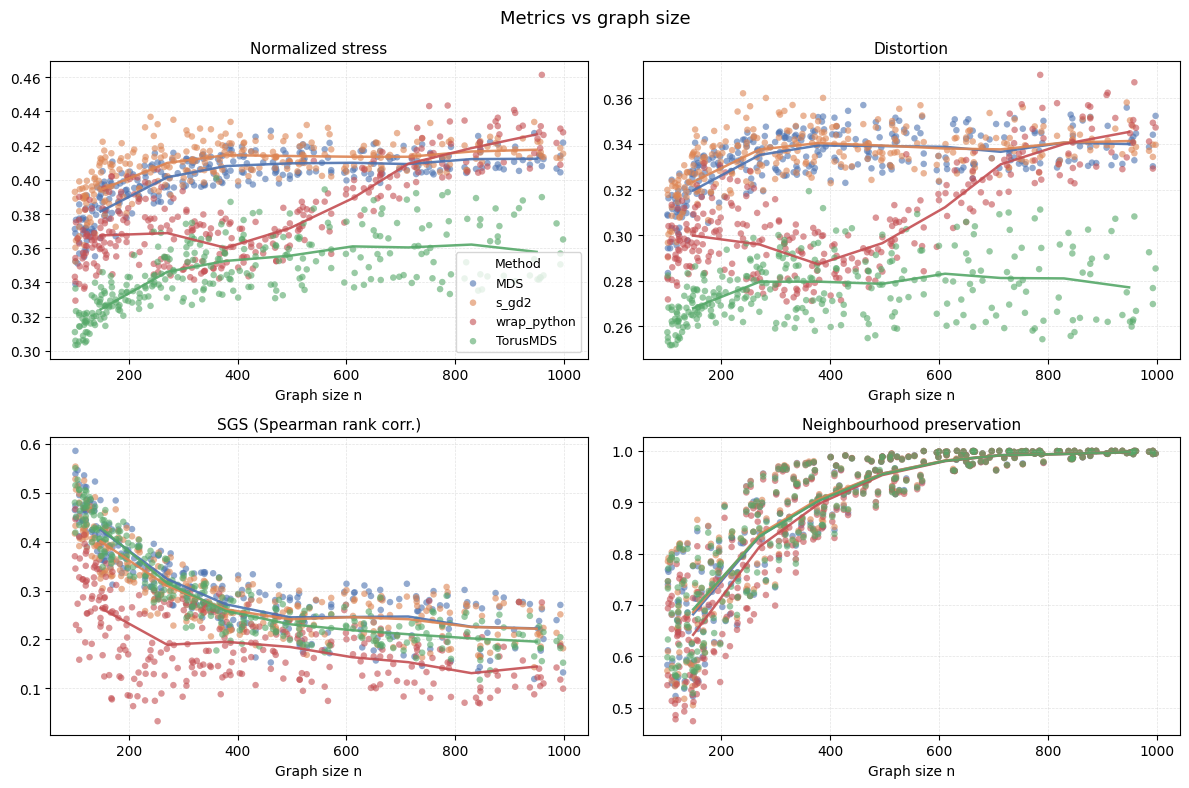

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, metric in zip(axes.flat, METRICS):
    for m in METHODS:
        d = data[m].sort_values('n')
        ax.scatter(d['n'], d[metric], s=22, color=COLORS[m],
                   alpha=0.6, label=m, edgecolors='none')
        # LOWESS-style trend via binned means
        bins = pd.cut(d['n'], bins=8)
        trend = d.groupby(bins, observed=True)[metric].mean()
        mids  = d.groupby(bins, observed=True)['n'].mean()
        ax.plot(mids.values, trend.values, color=COLORS[m], linewidth=1.8, alpha=0.9)

    ax.set_xlabel('Graph size n', fontsize=10)
    ax.set_title(LABELS[metric], fontsize=11)
    ax.grid(linestyle='--', alpha=0.35)

axes.flat[0].legend(title='Method', fontsize=9, title_fontsize=9)
fig.suptitle('Metrics vs graph size', fontsize=13)
fig.tight_layout()
plt.savefig('./results/sbm_metrics_vs_n.png', dpi=150, bbox_inches='tight')
plt.show()

## Metrics vs number of blocks k

/tmp/ipykernel_22346/122428000.py:21: UserWarning: Glyph 65023 (\N{ARABIC LIGATURE AZZA WA JALL}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_22346/122428000.py:22: UserWarning: Glyph 65023 (\N{ARABIC LIGATURE AZZA WA JALL}) missing from font(s) DejaVu Sans.
  plt.savefig('./results/metrics_vs_k.png', dpi=150, bbox_inches='tight')
/home/wsl/.virtualenvs/Torus-mds/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65023 (\N{ARABIC LIGATURE AZZA WA JALL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


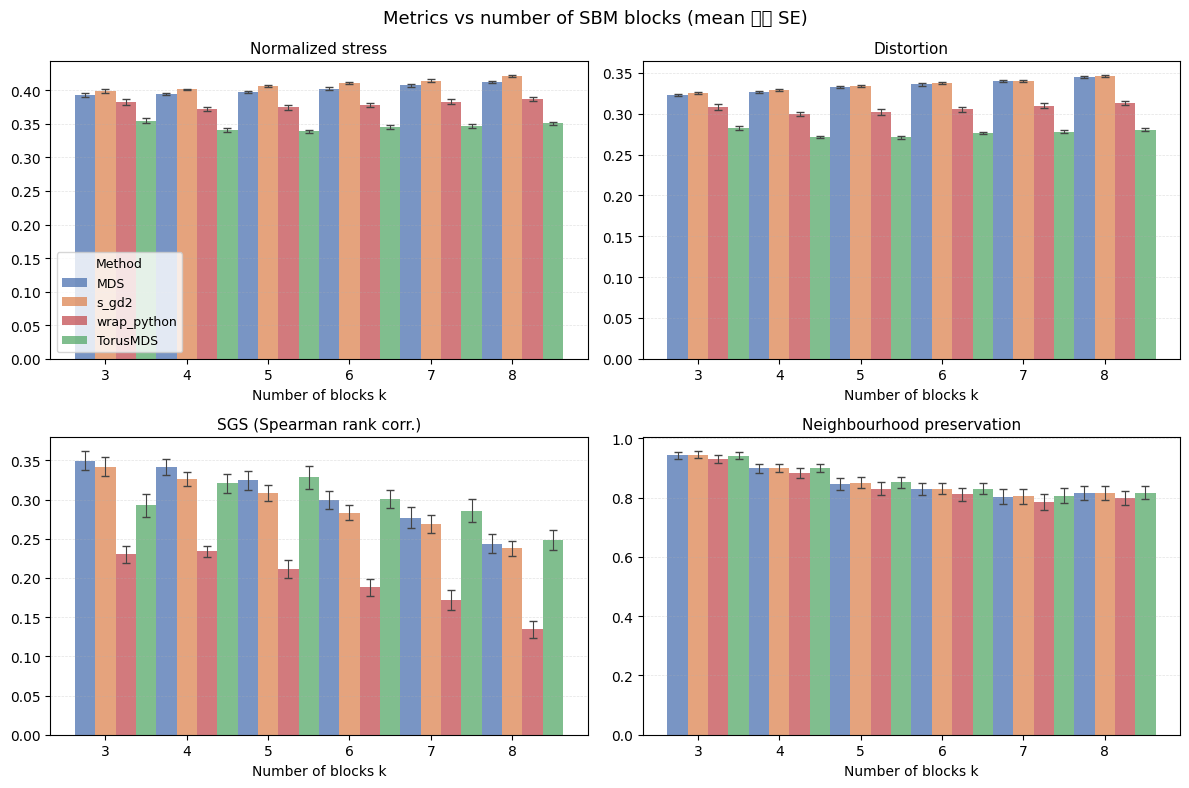

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
w = 0.25   # bar width
ks = sorted(df['k'].unique())

for ax, metric in zip(axes.flat, METRICS):
    for xi, m in enumerate(METHODS):
        means = [data[m][data[m]['k'] == k][metric].mean() for k in ks]
        sems  = [data[m][data[m]['k'] == k][metric].sem()  for k in ks]
        offsets = np.array(ks) + (xi - 1) * w
        ax.bar(offsets, means, width=w, color=COLORS[m],
               alpha=0.75, label=m, yerr=sems, capsize=3,
               error_kw=dict(elinewidth=0.8, ecolor='#444'))

    ax.set_xticks(ks)
    ax.set_xlabel('Number of blocks k', fontsize=10)
    ax.set_title(LABELS[metric], fontsize=11)
    ax.grid(axis='y', linestyle='--', alpha=0.35)

axes.flat[0].legend(title='Method', fontsize=9, title_fontsize=9)
fig.suptitle('Metrics vs number of SBM blocks (mean ﷿﷿ SE)', fontsize=13)
fig.tight_layout()
plt.savefig('./results/sbm_metrics_vs_k.png', dpi=150, bbox_inches='tight')
plt.show()

## Running time distributions

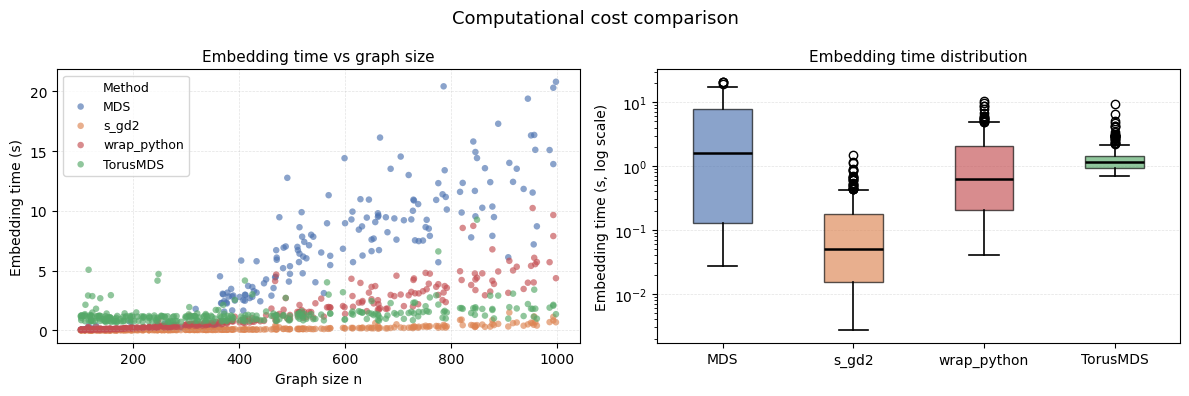

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: scatter t_embed vs n
ax = axes[0]
for m in METHODS:
    d = data[m]
    ax.scatter(d['n'], d['t_embed'], s=22, color=COLORS[m],
               alpha=0.65, label=m, edgecolors='none')
ax.set_xlabel('Graph size n', fontsize=10)
ax.set_ylabel('Embedding time (s)', fontsize=10)
ax.set_title('Embedding time vs graph size', fontsize=11)
ax.legend(title='Method', fontsize=9, title_fontsize=9)
ax.grid(linestyle='--', alpha=0.35)

# Right: log-scale box plot
ax = axes[1]
bp = ax.boxplot(
    [data[m]['t_embed'].values for m in METHODS],
    patch_artist=True,
    medianprops=dict(color='black', linewidth=1.8),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2),
)
for patch, m in zip(bp['boxes'], METHODS):
    patch.set_facecolor(COLORS[m])
    patch.set_alpha(0.65)
ax.set_yscale('log')
ax.set_xticks(range(1, len(METHODS) + 1))
ax.set_xticklabels(METHODS, fontsize=10)
ax.set_ylabel('Embedding time (s, log scale)', fontsize=10)
ax.set_title('Embedding time distribution', fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.35)
ax.yaxis.set_minor_locator(mticker.LogLocator(subs='all', numticks=10))

fig.suptitle('Computational cost comparison', fontsize=13)
fig.tight_layout()
plt.savefig('./results/sbm_timing.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary table

In [12]:
summary = df.groupby('method')[METRICS + ['t_embed']].agg(['mean', 'median', 'std'])
summary.columns = [f'{m}_{s}' for m, s in summary.columns]
summary = summary.round(4)
summary

,stress_mean,stress_median,stress_std,distortion_mean,distortion_median,distortion_std,sgs_mean,sgs_median,sgs_std,np_score_mean,np_score_median,np_score_std,t_embed_mean,t_embed_median,t_embed_std
method,,,,,,,,,,,,,,,
MDS,0.4006,0.4043,0.0156,0.3330,0.3335,0.0126,0.3094,0.2932,0.0904,0.8616,0.9068,0.1385,4.1807,1.6065,5.0461
TorusMDS,0.3464,0.3436,0.0204,0.2766,0.2749,0.0139,0.2971,0.2690,0.0965,0.8639,0.9071,0.1340,1.3659,1.1732,0.8575
s_gd2,0.4082,0.4106,0.0140,0.3348,0.3360,0.0119,0.2979,0.2813,0.0814,0.8638,0.9082,0.1376,0.1383,0.0495,0.2071
wrap_python,0.3794,0.3745,0.0257,0.3060,0.3013,0.0220,0.1984,0.1878,0.0813,0.8456,0.8991,0.1542,1.4528,0.6324,1.8146
